# Homework 4: Neural Networks


This assignment is due on Gradescope by **11:59pm on Friday, May 22nd**. 
Your solutions to theoretical questions should be done in Markdown/Latex directly below the associated question.
Your solutions to computational questions should include any specified Python code and results 
as well as written commentary on your conclusions.
Remember that you are encouraged to discuss the problems with your instructors and classmates, 
but **you must write all code and solutions on your own**. 


**NOTES**: 

- Some problems with code may be autograded.  If we provide a function API **do not** change it.  If we do not provide a function API then you're free to structure your code however you like. 
- Submit this Jupyter notebook and a PDF of your ouput to Canvas.  Do not compress it using tar, rar, zip, etc. 
- In this homework, we will use [PyTorch](https://pytorch.org/) to implement a classifier. Install the current stable release for PyTorch (instructions on homepage of Pytorch website). We recommend you use Anaconda for these installations in a virtual environment but you can use pip as well. For this homework, this command should be sufficient `pip3 install torch`.

It is **highly recommended** you install the CPU-only version of PyTorch if your'e unfamiliar with the process of installing CUDA libraries for these packages. If you choose to install a GPU version, ensure you're code runs without GPU support.

**Put your name here:**

**Name**

In [1]:
# Test PyTorch installation
# Please do not edit this cell
import torch 
import math
import pickle
import gzip
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

torch.manual_seed(1234)

In [2]:
# Put your imports (if any) here

[26 points] Problem 1 - Single-Layer and Multilayer Perceptron Learning
---

### Part 1 [13 points] 
In general, a *single-layer perceptron* is a neural network with an input layer, no hidden layers, and an output layer. *Multilayer perceptrons* can have one or more hidden layers. 

Consider learning the following concepts with either a single-layer or multilayer perceptron where all hidden and output neurons utilize the *indicator* activation functions. For each of the following concepts, state whether the concept can be learned by a single-layer perceptron. 

Briefly justify your response by providing weights, biases, and the indicator activation functions if applicable:

- NOT \(x_1\)

- \(x_1\) NAND \(x_2\)

- \(x_1\) XNOR \(x_2\) (output 1 when \(x_1 = x_2\) and 0 otherwise)

Each perceptron uses the following indicator activation function:

$$
\mathbb{1}[w^\top x + b > 0].
$$

Also, single layer perceptron can only learn linearly separable data. 

### 1. NOT x<sub>1</sub>

This concept **can** be learned by a single-layer perceptron. 

$$
w_1 = -1, \qquad b = 0.5.
$$

Then

$$
h(x_1) = \mathbb{1}[-x_1 + 0.5 > 0].
$$

### 2. x<sub>1</sub> NAND x<sub>2</sub>

This concept **can** be learned by a single-layer perceptron. 

$$
w_1 = -1, \qquad w_2 = -1, \qquad b = 1.5.
$$

Then

$$
h(x_1,x_2)=\mathbb{1}[-x_1-x_2+1.5>0].
$$

### 3. x<sub>1</sub> XNOR x<sub>2</sub>

This concept **cannot** be learned by a single-layer perceptron because it is not linearly separable:

$$
(0,0)\mapsto 1,\quad
(1,1)\mapsto 1,\quad
(1,0)\mapsto 0,\quad
(0,1)\mapsto 0.
$$

However, XNOR can be learned by a multilayer perceptron. Use hidden units

$$
z_1 = \mathbb{1}[x_1+x_2-1.5>0]
$$

and

$$
z_2 = \mathbb{1}[-x_1-x_2+0.5>0].
$$

Then use output

$$
h(x_1,x_2)=\mathbb{1}[z_1+z_2-0.5>0].
$$

### Part 2 [13 points] 

Determine an architecture and specific values of the weights and biases in a single-layer or multilayer perceptron with indicator activation functions that can learn \(x_1\) XNOR \(x_2\). Make a truth table of \(x_1\), \(x_2\), and \(x_1\) XNOR \(x_2\), describe your perceptron's architecture, and state your weight matrices and bias vectors in Markdown below. Then demonstrate that your solution is correct by implementing forward propagation for your network in Python and showing that it produces the correct boolean output values for each of the four possible combinations of \(x_1\) and \(x_2\).

### Part 2

The function \(x_1\) XNOR \(x_2\) outputs 1 when \(x_1=x_2\), and 0 otherwise.

| \(x_1\) | \(x_2\) | \(x_1\) XNOR \(x_2\) |
|---:|---:|---:|
| 0 | 0 | 1 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

A single-layer perceptron cannot learn XNOR because XNOR is not linearly separable.  
However, it can be learned by a multilayer perceptron with one hidden layer.

Use two hidden neurons:

$$
z_1 = \mathbb{1}[x_1 + x_2 - 1.5 > 0]
$$

This hidden neuron computes \(x_1 \land x_2\), which means \(x_1\) AND \(x_2\).


$$
z_2 = \mathbb{1}[-x_1 - x_2 + 0.5 > 0]
$$

This hidden neuron computes NOT \(x_1\) AND NOT \(x_2\).

The output neuron computes

$$
h(x_1,x_2)=\mathbb{1}[z_1+z_2-0.5>0].
$$

Therefore, the network computes

$$
(x_1 \land x_2) \lor (\neg x_1 \land \neg x_2),
$$

which is exactly \(x_1\) XNOR \(x_2\).

The hidden-layer weight matrix and bias vector are

$$
W^{(1)}
=
\begin{bmatrix}
1 & 1 \\
-1 & -1
\end{bmatrix},
\qquad
b^{(1)}
=
\begin{bmatrix}
-1.5 \\
0.5
\end{bmatrix}.
$$

The output-layer weight matrix and bias vector are

$$
W^{(2)}
=
\begin{bmatrix}
1 & 1
\end{bmatrix},
\qquad
b^{(2)}
=
\begin{bmatrix}
-0.5
\end{bmatrix}.
$$

In [3]:
import numpy as np

def indicator(a):
    return (a > 0).astype(int)

W1 = np.array([
    [1, 1],
    [-1, -1]
])

b1 = np.array([-1.5, 0.5])

W2 = np.array([
    [1, 1]
])

b2 = np.array([-0.5])

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

Z = indicator(X @ W1.T + b1)
Y = indicator(Z @ W2.T + b2)

print("x1 x2 | XNOR")
print("-------------")
for x, y in zip(X, Y):
    print(f"{x[0]}  {x[1]}  |  {y[0]}")

x1 x2 | XNOR
-------------
0  0  |  1
0  1  |  0
1  0  |  0
1  1  |  1


[30 points] Problem 2 - Backpropagation
---

In this problem you will gain some intuition about why training deep neural networks can be very time consuming.  Consider training a chain-like neural network: 

![chain-like nn](figs/chain_net.png)

Note that this network has three weights $W^1, W^2, W^3$ and three biases $b^1, b^2,$ and $b^3$ (for this problem you can think of each parameter as a single value or as a $1 \times 1$ matrix). Suppose that each hidden and output neuron is equipped with a sigmoid activation function and the loss function is given by 

$$
\ell(y, a^3) = \frac{1}{2}(y - a^3)^2  
$$

where $a^3$ is the value of the activation at the output neuron and $y \in \{0,1\}$ is the true label associated with the training example.  

**Note**: Superscripts on $W$'s, $b$'s, and $a$'a are being used as indices and not powers here (e.g. $a^3$ indicates the 3rd activation value, not the activation value $a$ to the 3rd power.)

### Part 1 [5 points]
Suppose each of the weights is initialized to $W^k = 1.0$ and each bias is initialized to $b^k = -0.5$.  Use forward propagation to find the activities and activations associated with each hidden and output neuron for the training example $(x, y) = (0.5,0)$. Show your work. 

The sigmoid activation function is

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

For this network, each layer has one weight and one bias. The activity at layer \(k\) is

$$
z^k = W^k a^{k-1} + b^k,
$$

and the activation is

$$
a^k = \sigma(z^k).
$$

The input is

$$
a^0 = x = 0.5.
$$

We are given

$$
W^1=W^2=W^3=1.0
$$

and

$$
b^1=b^2=b^3=-0.5.
$$

#### First hidden neuron

The activity is

$$
z^1 = W^1a^0+b^1.
$$

Substituting the values,

$$
z^1 = (1.0)(0.5)-0.5 = 0.
$$

Therefore, the activation is

$$
a^1 = \sigma(z^1)=\sigma(0)=\frac{1}{1+e^0}=\frac{1}{2}=0.5.
$$

#### Second hidden neuron

The activity is

$$
z^2 = W^2a^1+b^2.
$$

Substituting the values,

$$
z^2 = (1.0)(0.5)-0.5 = 0.
$$

Therefore, the activation is

$$
a^2 = \sigma(z^2)=\sigma(0)=\frac{1}{2}=0.5.
$$

#### Output neuron

The activity is

$$
z^3 = W^3a^2+b^3.
$$

Substituting the values,

$$
z^3 = (1.0)(0.5)-0.5 = 0.
$$

Therefore, the activation is

$$
a^3 = \sigma(z^3)=\sigma(0)=\frac{1}{2}=0.5.
$$

Thus, the activities are

$$
z^1=0,\qquad z^2=0,\qquad z^3=0.
$$

The activations are

$$
a^1=0.5,\qquad a^2=0.5,\qquad a^3=0.5.
$$

### Part 2 [8 points]:
Use backpropagation to compute the weight and bias derivatives $\partial \ell / \partial W^k$ and $\partial \ell / \partial b^k$ for $k=1, 2, 3$.  Show all work. 

### Problem 2, Part 2

From Part 1, we found

$$
z^1=z^2=z^3=0
$$

and

$$
a^0=x=0.5,\qquad a^1=a^2=a^3=0.5.
$$

The loss is

$$
\ell(y,a^3)=\frac{1}{2}(y-a^3)^2.
$$

Since \(y=0\) and \(a^3=0.5\),

$$
\frac{\partial \ell}{\partial a^3}
=
a^3-y
=
0.5-0
=
0.5.
$$

The sigmoid derivative is

$$
\sigma'(z)=\sigma(z)(1-\sigma(z)).
$$

Since each \(z^k=0\), each activation is \(0.5\), so

$$
\sigma'(z^k)=0.5(1-0.5)=0.25.
$$

#### Output layer derivatives

Define

$$
\delta^3
=
\frac{\partial \ell}{\partial z^3}.
$$

Then

$$
\delta^3
=
\frac{\partial \ell}{\partial a^3}
\frac{\partial a^3}{\partial z^3}
=
0.5(0.25)
=
0.125.
$$

Since

$$
z^3=W^3a^2+b^3,
$$

we have

$$
\frac{\partial \ell}{\partial W^3}
=
\delta^3 a^2
=
0.125(0.5)
=
0.0625,
$$

and

$$
\frac{\partial \ell}{\partial b^3}
=
\delta^3
=
0.125.
$$

#### Second hidden layer derivatives

Now compute

$$
\delta^2
=
\frac{\partial \ell}{\partial z^2}.
$$

Using backpropagation,

$$
\delta^2
=
\delta^3 W^3 \sigma'(z^2).
$$

Substituting,

$$
\delta^2
=
0.125(1.0)(0.25)
=
0.03125.
$$

Since

$$
z^2=W^2a^1+b^2,
$$

we have

$$
\frac{\partial \ell}{\partial W^2}
=
\delta^2 a^1
=
0.03125(0.5)
=
0.015625,
$$

and

$$
\frac{\partial \ell}{\partial b^2}
=
\delta^2
=
0.03125.
$$

#### First hidden layer derivatives

Now compute

$$
\delta^1
=
\frac{\partial \ell}{\partial z^1}.
$$

Using backpropagation,

$$
\delta^1
=
\delta^2 W^2 \sigma'(z^1).
$$

Substituting,

$$
\delta^1
=
0.03125(1.0)(0.25)
=
0.0078125.
$$

Since

$$
z^1=W^1a^0+b^1,
$$

we have

$$
\frac{\partial \ell}{\partial W^1}
=
\delta^1 a^0
=
0.0078125(0.5)
=
0.00390625,
$$

and

$$
\frac{\partial \ell}{\partial b^1}
=
\delta^1
=
0.0078125.
$$

Therefore, the final derivatives are

$$
\frac{\partial \ell}{\partial W^1}=0.00390625,
\qquad
\frac{\partial \ell}{\partial b^1}=0.0078125,
$$

$$
\frac{\partial \ell}{\partial W^2}=0.015625,
\qquad
\frac{\partial \ell}{\partial b^2}=0.03125,
$$

$$
\frac{\partial \ell}{\partial W^3}=0.0625,
\qquad
\frac{\partial \ell}{\partial b^3}=0.125.
$$

### Part 3 [5 points]
Implement the following activation functions in NumPy:
* ReLU
* Sigmoid
* softmax

Please **do not use any other external libraries** for this such as sklearn.

**Note**: Assume the input `x` is a 1-dimensional numpy array with $n$ entries (i.e. `x.shape` is `(n,)`). The expected output is an array with the same shape.

In [4]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

In [5]:
import numpy as np
import torch

print("numpy:", np.__version__)
print("torch:", torch.__version__)

torch.from_numpy(np.array([1.0, 2.0, 3.0]))

numpy: 2.4.6
torch: 2.12.0


tensor([1., 2., 3.], dtype=torch.float64)

In [6]:
import sys
print(sys.executable)

/Users/danielaavayu/Desktop/CAPP/Year 1/Q3/ML/Homeworks/homework4-daniavayu/.venv/bin/python


In [7]:
# random tests for checking your impementation.
from tests import tests
tests.run_test_suite('prob 2.3', (relu, sigmoid, softmax))

TestRelu (tests.tests.TestActiv.TestRelu) ... ok
TestSigmoid (tests.tests.TestActiv.TestSigmoid) ... ok
TestSoftmax (tests.tests.TestActiv.TestSoftmax) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.010s

OK


### Part 4 [6 points] 
Implement the following loss functions in NumPy:
* mean squared error
* mean absolute error
* average hinge loss

Please **do not use any other external libraries** for this such as sklearn.

**Note**: Assume that the inputs `y` and `yhat` are both 1-dimensional numpy arrays with $n$ entries. The expected output is a float.

In [11]:
def mean_squared_error(yhat, y):
    return np.mean((yhat - y) ** 2)
    
def mean_absolute_error(yhat, y):
    return np.mean(np.abs(yhat - y))

def hinge_loss(yhat, y):
    return np.mean(np.maximum(0, 1 - y * yhat))

In [12]:
# random tests for checking your impementation.
from tests import tests
tests.run_test_suite('prob 2.4', (mean_squared_error, mean_absolute_error))

TestMSE (tests.tests.TestLoss.TestMSE) ... 

ok
TestMAE (tests.tests.TestLoss.TestMAE) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.067s

OK


MSE averages squared errors.
MAE averages absolute errors.
Hinge loss penalizes predictions that are on the wrong side of the margin.

### Part 5 [6 points]
Explain the vanishing gradient problem. When would you observe this? Give an example.

The vanishing gradient problem happens when gradients become very small as they are backpropagated through a neural network. In deep networks, each layer's gradient depends on the gradients from later layers multiplied by derivatives from the current layer. If these derivatives are small, then repeatedly multiplying them together can make the gradients shrink toward zero.

This is especially common when using sigmoid activation functions. The derivative of the sigmoid function is

$$
\sigma'(z)=\sigma(z)(1-\sigma(z)).
$$

The largest possible value of this derivative is \(0.25\). Therefore, when backpropagating through many sigmoid layers, the gradient can repeatedly get multiplied by numbers less than 1. For example, after several layers, a gradient may contain a factor like

$$
(0.25)^k,
$$

where \(k\) is the number of layers. As \(k\) increases, this value becomes very small.

When gradients vanish, the weights in early layers update very slowly or almost not at all. This makes training deep neural networks difficult because the earlier layers do not learn useful features efficiently.

You would observe the vanishing gradient problem when training a deep network, especially one with many layers and sigmoid or tanh activations. For example, in the chain-like network from this problem, each layer uses a sigmoid activation. If the network had many more layers, the gradient for the earliest weight \(W^1\) would become much smaller than the gradient for later weights such as \(W^3\). As a result, \(W^1\) would learn much more slowly.


[30 Points] Problem 3 - Build a feedforward neural network in NumPy
---

In this problem you will implement a class representing a general feed-forward neural network that utilizes the sigmoid activation functions. Your tasks will be to implement forward propagation, prediction, backpropagation, and a general train routine to learn the weights in your network via stochastic gradient descent.

The skeleton for the network class is below.

In [13]:
import argparse
import numpy as np
import pickle
import gzip
import matplotlib.pyplot as plt


class Network:
    def __init__(self, sizes):
        self.L = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(n, 1) for n in self.sizes[1:]]
        self.weights = [np.random.randn(n, m) for (
            m, n) in zip(self.sizes[:-1], self.sizes[1:])]
        self.acc_train_array = []
        self.acc_test_array = []

    def g(self, z):
        """
        activation function
        """
        return sigmoid(z)

    def g_prime(self, z):
        """
        derivative of activation function
        """
        return sigmoid_prime(z)

    def forward_prop(self, a):
        """
        memory aware forward propagation for testing
        only.  back_prop implements its own forward_prop
        should take in weights and biases and return output value
        """
        for W, b in zip(self.weights, self.biases):
            z = np.dot(W, a) + b
            a = self.g(z)
        return a

    def grad_cost(self, a, y):
        """
        gradient of cost function
        Assumes C(a,y) = (a-y)^2/2
        """
        return (a - y)
    
    def log_train_progress(self, train, test, epoch):
        """ Logs training progres. 
        """
        acc_train = self.evaluate(train)
        self.acc_train_array.append(acc_train)
        if test is not None:
            acc_test = self.evaluate(test)
            self.acc_test_array.append(acc_test)
            print("Epoch {:4d}: Train {:10.5f}, Test {:10.5f}".format(
                epoch+1, acc_train, acc_test))
        else:
            print("Epoch {:4d}: Train {:10.5f}".format(
                epoch+1, acc_train))
            

    def SGD_train(self, train, epochs, eta, lam=0.0, verbose=True, test=None):
        """
        SGD for training parameters
        epochs is the number of epocs to run
        eta is the learning rate
        lam is the regularization parameter
        If verbose is set will print progressive accuracy updates
        If test set is provided, routine will print accuracy on test set as learning evolves
        """
        n_train = len(train)
        for epoch in range(epochs):
            perm = np.random.permutation(n_train)
            for kk in range(n_train):
                self.SGD_step(*train[perm[kk]], eta, lam)
            if verbose and epoch == 0 or (epoch + 1) % 20 == 0:
                self.log_train_progress(train, test, epoch)
    
    def SGD_step(self, x, y, eta, lam):
        """
        TODO: get gradients with x, y and do SGD on weights and biases

        Args:
            x: single sample features.
            y: single sample target.
            eta: learning rate.
            lam: Regularization parameter.
                
        """
        # TODO: get gradients with xk, yk and do SGD on and update weights and biases
        dW_list, db_list = self.back_prop(x, y)

        for ell in range(len(self.weights)):
            self.weights[ell] = self.weights[ell] - eta * (
                dW_list[ell] + lam * self.weights[ell]
            )
            self.biases[ell] = self.biases[ell] - eta * db_list[ell]

    def back_prop(self, x, y):
        """
        Backpropagation for derivatives of C wrt parameters
        """
        db_list = [np.zeros(b.shape) for b in self.biases]
        dW_list = [np.zeros(W.shape) for W in self.weights]
        
        a = x
        a_list = [a]
        z_list = [np.zeros(a.shape)]  # Pad with a placeholder so that indices match

        for W, b in zip(self.weights, self.biases):
            z = np.dot(W, a) + b
            z_list.append(z)
            a = self.g(z)
            a_list.append(a)

        # Back propagate deltas to compute derivatives
        # The following list gives hints on how to do it
        # calculating delta (Error) for the output layer
        # for the appropriate layers compute db_list[ell], dW_list[ell], delta
        # use functions above for your solution

        delta = self.grad_cost(a_list[-1], y) * self.g_prime(z_list[-1])
        db_list[-1] = delta
        dW_list[-1] = np.dot(delta, a_list[-2].T)
    
        for ell in range(2, self.L):
            z = z_list[-ell]
            delta = np.dot(self.weights[-ell + 1].T, delta) * self.g_prime(z)
            db_list[-ell] = delta
            dW_list[-ell] = np.dot(delta, a_list[-ell - 1].T)
    
        return (dW_list, db_list)
        return (dW_list, db_list)
    

    def evaluate(self, test):
        """
        Evaluate current model on labeled test data
        """
        ctr = 0
        for x, y in test:
            yhat = self.forward_prop(x)
            ctr += yhat.argmax() == y.argmax()
        return float(ctr) / float(len(test))


def sigmoid(z, threshold=20):
    z = np.clip(z, -threshold, threshold)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_prime(z):
    return sigmoid(z) * (1.0 - sigmoid(z))


def mnist_digit_show(flatimage, outname=None):

    import matplotlib.pyplot as plt

    image = np.reshape(flatimage, (-1, 14))

    plt.matshow(image, cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    if outname:
        plt.savefig(outname)
    else:
        plt.show()

### Part 1 [20 points]
Implement `SGD_step`, `back_prop`, and `forward_prop`. Use the following test cases to verify if the code is working as expected.

In [14]:
from tests import tests
tests.run_test_suite('prob 3', Network)

TestBackPropWithoutRegularization (tests.tests.TestNetwork.TestBackPropWithoutRegularization) ... ok
TestBackPropWithRegularization (tests.tests.TestNetwork.TestBackPropWithRegularization) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.125s

OK


### Part 2 [10 points]

Run the above Network on MNIST Dataset and report the following (feel free to experiment with different learning rates).

* Change the hidden layer dimensions and experiment with these values: [5, 10, 20].
* Plot accuracies of different hidden layer dimensions vs. epochs for both training and testing.
* Explain the effect of hidden layer dimension on performance. 

**Note:** Accuracies are stored in `self.acc_train_array` and `self.acc_test_array` if `verbose` is `True`.

In [15]:
location = './data/tinyMNIST.pkl.gz'
f = gzip.open(location, 'rb')
u = pickle._Unpickler(f)
u.encoding = 'latin1'
train, test = u.load()
input_dimensions = len(train[0][0])
output_dimensions = len(train[0][1])
print('Number of Input Features: ', input_dimensions)
print('Number of Output classes: ', output_dimensions)

nns = []
for hidden_layer_dimensions in [5, 10, 20]:
    print('\nHidden Layer Dimensions: ', hidden_layer_dimensions)
    nn = Network([input_dimensions, hidden_layer_dimensions, output_dimensions])
    nns.append(nn)
    nn.SGD_train(train, epochs=200, eta=0.1, lam=0.0001, verbose=True, test=test)

Number of Input Features:  196
Number of Output classes:  10

Hidden Layer Dimensions:  5
Epoch    1: Train    0.15726, Test    0.16567
Epoch   20: Train    0.81753, Test    0.73349
Epoch   40: Train    0.87635, Test    0.79392
Epoch   60: Train    0.88756, Test    0.79832
Epoch   80: Train    0.88956, Test    0.80152
Epoch  100: Train    0.89116, Test    0.79952
Epoch  120: Train    0.89836, Test    0.80072
Epoch  140: Train    0.89476, Test    0.79472
Epoch  160: Train    0.89156, Test    0.80112
Epoch  180: Train    0.89636, Test    0.79752
Epoch  200: Train    0.90036, Test    0.79952

Hidden Layer Dimensions:  10
Epoch    1: Train    0.26371, Test    0.26371
Epoch   20: Train    0.90996, Test    0.83954
Epoch   40: Train    0.93637, Test    0.85914
Epoch   60: Train    0.94078, Test    0.86435
Epoch   80: Train    0.94638, Test    0.86234
Epoch  100: Train    0.94478, Test    0.86234
Epoch  120: Train    0.94838, Test    0.86154
Epoch  140: Train    0.94838, Test    0.86795
Epoch 

Plot training and testing accuracies below for each configuration. Use solid lines for testing accuracy, and dotted lines for train accuracy (`ls='dashed'`). 

Be sure to label your lines and match colors accordingly.

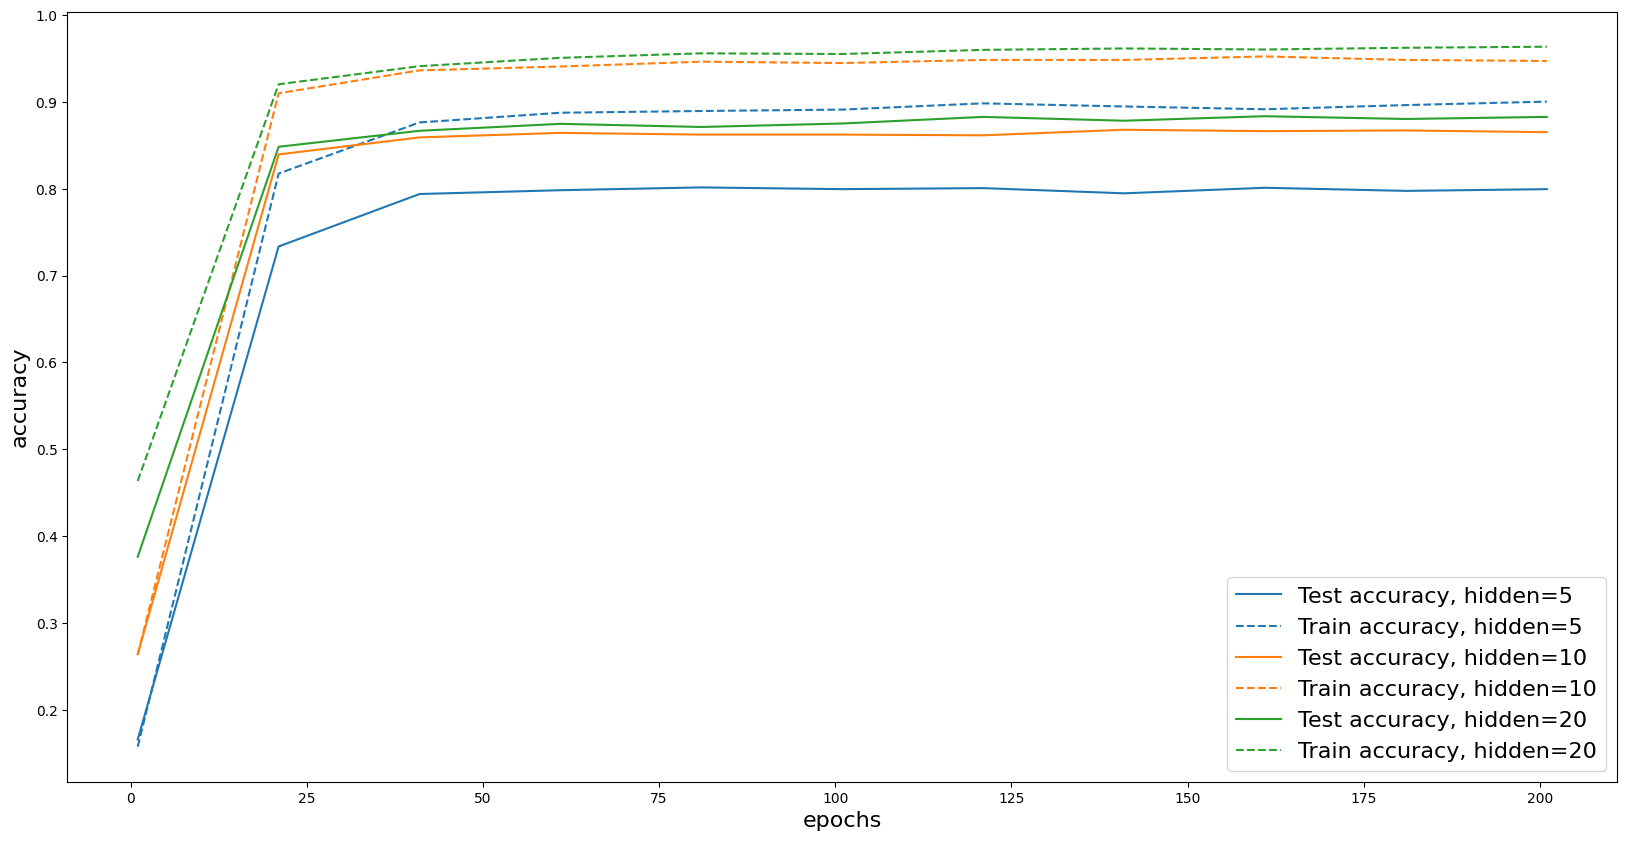

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,10))
epochs_array = [i for i in range(1, 220, 20)]

hidden_layer_dimensions = [5, 10, 20]
colors = ["tab:blue", "tab:orange", "tab:green"]

for nn, hidden_dim, color in zip(nns, hidden_layer_dimensions, colors):
    ax.plot(
        epochs_array,
        nn.acc_test_array,
        color=color,
        linestyle="solid",
        label=f"Test accuracy, hidden={hidden_dim}"
    )
    
    ax.plot(
        epochs_array,
        nn.acc_train_array,
        color=color,
        linestyle="dashed",
        label=f"Train accuracy, hidden={hidden_dim}"
    )

ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("accuracy", fontsize=16)
plt.show()

Give your explanation below.

As the hidden layer dimension increases from 5 to 10 to 20, the neural network has more parameters and therefore more capacity to learn patterns in the MNIST data. A larger hidden layer can represent more complicated decision boundaries, so we generally expect the training accuracy to improve as the hidden dimension increases.

The test accuracy may also improve when increasing the hidden dimension, especially if the smaller network is underfitting. However, if the hidden layer becomes too large relative to the amount of training data, the model may start to overfit. In that case, training accuracy can continue to increase while test accuracy improves more slowly or even decreases.

In this experiment, comparing the solid test-accuracy lines with the dashed training-accuracy lines shows how model capacity affects learning. If the 20-unit hidden layer has the highest training accuracy but not the highest test accuracy, that suggests some overfitting. If both training and test accuracy improve with hidden dimension, then the larger hidden layer is helping the model learn useful structure from the data.

## [14 points] Problem 4 - Tensors and Autograd
In this problem, we will demonstrate the benefits of PyTorch's Autograd mechanics by converting your implementation from Problem 3 to utilize PyTorch Tensors. This problem is not meant to be difficult, rather it should be quite simple once you've done Problem 3.

Note that there are other ways to go about this. We are keeping things as close to NumPy as possible on purpose. Take a moment to look through our modifications to get an understanding of the differences. In the comments, we'll make notes of native torch functions that perform the same operations. 

Here, SGD is implemented manually to show you what's going on behind the scenes, but  usually you'd use [`torch.optim.SGD`](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD). For reference, the `weight_decay` parameter implements L2 normalization. 

--- 

Before we move forward, let's cover a couple of points on notation. 

Just as it's best practice to do `import numpy as np`, PyTorch has best practices for imports as well:

```python
import torch 
import torch.nn as nn
import torch.nn.functional as F
```
You'll find that many of the functions you've been learning in NumPy have direct translations in PyTorch. The documentation can be found [here](https://pytorch.org/docs/stable/index.html) and is very user friendly, but we'll cover a few notable differences. 

- The numpy parameter `axis` becomes `dim` in PyTorch.
- Tensors have [view](https://pytorch.org/docs/stable/tensor_view.html) operations, which avoid copying data unnecasarily. Use these instead of `reshape()`. 
- Using `torch.from_numpy()` also avoids copying data stored in `numpy` arrays.
- Numpy interprets `np.dot()` of 2D matrices as matrix multiplication. Pytorch does not have this behaviour, see instead [`torch.matmul()`](https://pytorch.org/docs/stable/generated/torch.matmul.html?highlight=matmul#torch.matmul)
- PyTorch uses trailing underscores such as `torch.add_()` to denote in-place operations. As an example, the following operations are equivilent:
```python
x = x + y
x = torch.add(x, y)
x.add_(y)
```
You're likely to see these operations when randomly initializing Tensors, or filling a tensor with zeros:
```python
torch.nn.init.uniform_(x)
x.zero_()
```

---
Now onto the problem, your tasks are as follows:

1. Modify `forward_prop` to work on PyTorch Tensors.
2. Modify `SGD_step` to work on PyTorch Tensors. This is easier than it sounds, since with PyTorch we don't have to worry about calculating gradients manually.

In [17]:
import torch


class TorchNetwork(Network):
    def __init__(self, sizes, keep_prob=-1):
        super().__init__(sizes)
        
        # Convert your weights and biases to Tensors.
        # The flag requires_grad=True tells PyTorch to track gradients for us. 
        self.biases = [torch.tensor(b, requires_grad=True) for b in self.biases]
        self.weights = [torch.tensor(w, requires_grad=True) for w in self.weights]
        

    def g(self, z):
        """ Activation function
            Could also use torch.sigmoid(z)
        """
        return sigmoid_torch(z) 

    def forward_prop(self, a):
        """ Memory aware forward propagation. 
            Now this is for both training and testing.
        
        """
        # TODO: Convert your forward_prop function from part a to work on Tensors. 
        for W, b in zip(self.weights, self.biases):
            z = torch.matmul(W, a) + b
            a = self.g(z)
        return a

    def cost(self, a, y):
        """ Cost function, same as F.mse_loss()
        """
        return ((a - y)**2).mean() 
            

    def SGD_step(self, x, y, eta, lam):
        """
            Performs a single step of SGD on weights and biases

        Args:
            x: single sample features.
            y: single sample target.
            eta: learning rate.
            lam: Regularization parameter.
                
        """
        
        # Zero out the old gradients if they exist. 
        # Would be optim.zero_grad() if we were using an optimizer.
        for p in (*self.weights, *self.biases):
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()
            
        # TODO: 
        # (1) perform forward propogation
        # (2) use the loss fuction to calculate loss
        # (3) perform backpropogation

        # (1) perform forward propagation
        yhat = self.forward_prop(x)

        # (2) calculate loss
        loss = self.cost(yhat, y)

        # (3) perform backpropagation
        loss.backward()

        # Perform sgd update 
        # Would be optimizer.step()
        with torch.no_grad():
            # l2 regularization on weights only.
            for p in self.weights:
                p.grad.add_(p, alpha=lam)
            # sgd update. 
            for p in (*self.weights, *self.biases):
                p.add_(p.grad, alpha=-eta)
                

def sigmoid_torch(z, threshold=20):
    """ Same as sigmoid before, now with torch.clamp() instead of np.clip().
        We could also just use torch.sigmoid().
    """
    z = torch.clamp(z, -threshold, threshold)
    return 1.0 / (1.0 + torch.exp(-z))


In [ ]:
from tests import tests
tests.run_test_suite('new prob 4', TorchNetwork)
torch. __version__

TestBackPropWithoutRegularization (tests.tests.TestNetwork.TestBackPropWithoutRegularization) ... ok
TestBackPropWithRegularization (tests.tests.TestNetwork.TestBackPropWithRegularization) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.516s

OK


'2.12.0'

**Acknowledgment** : Chris Ketelsen, Chenhao Tan